<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/Sensor_fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install nuscenes-devkit open3d opencv-python matplotlib ultralytics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud, RadarPointCloud
import cv2
import numpy as np

DATA_ROOT = "/content/drive/MyDrive/nuscenes"

nusc = NuScenes(
    version="v1.0-mini",
    dataroot=DATA_ROOT ,
    verbose=True
)

sample = nusc.sample[0]

cam_token   = sample["data"]["CAM_FRONT"]
lidar_token = sample["data"]["LIDAR_TOP"]
radar_token = sample["data"]["RADAR_FRONT"]

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 12.864 seconds.
Reverse indexing ...
Done reverse indexing in 0.2 seconds.


Camera, LiDAR, Radar code

In [ ]:
# Camera

cam_sd = nusc.get("sample_data", cam_token)
img = cv2.imread(nusc.get_sample_data_path(cam_token))

In [ ]:
# LiDAR

lidar_sd = nusc.get("sample_data", lidar_token)
lidar_pc = LidarPointCloud.from_file(
    nusc.get_sample_data_path(lidar_token)
)
points_lidar = lidar_pc.points[:3].T  # (N,3)

In [ ]:
# Radar

radar_pc = RadarPointCloud.from_file(
    nusc.get_sample_data_path(radar_token)
)

radar_pts = radar_pc.points
radar_xyv = radar_pts[[0,1,8]].T  # x, y, velocity

Coordinate transformations

In [ ]:
def get_sensor_to_ego(nusc, sd_token):
    sd = nusc.get("sample_data", sd_token)
    cs = nusc.get("calibrated_sensor", sd["calibrated_sensor_token"])
    return cs

In [ ]:
from nuscenes.utils.geometry_utils import view_points
from pyquaternion import Quaternion

def project_lidar_to_image(nusc, lidar_token, cam_token, points):
    cam_sd = nusc.get("sample_data", cam_token)
    lidar_sd = nusc.get("sample_data", lidar_token)

    cam_cs = nusc.get("calibrated_sensor", cam_sd["calibrated_sensor_token"])
    lidar_cs = nusc.get("calibrated_sensor", lidar_sd["calibrated_sensor_token"])

    K = np.array(cam_cs["camera_intrinsic"])

    # Convert quaternions to rotation matrices
    lidar_rot_matrix = Quaternion(lidar_cs["rotation"]).rotation_matrix
    cam_rot_matrix = Quaternion(cam_cs["rotation"]).rotation_matrix

    # Transform lidar → ego → cam
    lidar_pc = LidarPointCloud(points.T)
    lidar_pc.rotate(lidar_rot_matrix)
    lidar_pc.translate(lidar_cs["translation"])

    lidar_pc.rotate(np.linalg.inv(cam_rot_matrix))
    lidar_pc.translate(-np.array(cam_cs["translation"]))

    pts_img = view_points(lidar_pc.points[:3], K, normalize=True)
    return pts_img[:2].T

Camera detection

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model(img)[0]

detections = []
for box in results.boxes:
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
    detections.append((x1, y1, x2, y2))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 384x640 1 person, 4 cars, 1 truck, 341.4ms
Speed: 7.5ms preprocess, 341.4ms inference, 41.3ms postprocess per image at shape (1, 3, 384, 640)


LiDAR and Camera fusion

In [ ]:
import numpy as np

# points_lidar currently has shape (N, 3)
# The project_lidar_to_image function (specifically the LidarPointCloud constructor inside it)
# expects a (4, N) array for homogeneous coordinates.
# So, we need to transform points_lidar from (N, 3) to (N, 4) by adding a column of ones.
points_lidar_homogeneous = np.concatenate((points_lidar, np.ones((points_lidar.shape[0], 1))), axis=1)

img_pts = project_lidar_to_image(
    nusc, lidar_token, cam_token, points_lidar_homogeneous
)

fused = []

for (x1, y1, x2, y2) in detections:
    mask = (
        (img_pts[:,0] > x1) &
        (img_pts[:,0] < x2) &
        (img_pts[:,1] > y1) &
        (img_pts[:,1] < y2)
    )

    cluster = points_lidar[mask]

    if len(cluster) > 10:
        centroid = cluster.mean(axis=0)
        fused.append({"pos": centroid})

Radar

In [ ]:
def attach_velocity(objects, radar_xyv):
    for obj in objects:
        dx = radar_xyv[:,0] - obj["pos"][0]
        dy = radar_xyv[:,1] - obj["pos"][1]
        d = np.sqrt(dx**2 + dy**2)
        idx = np.argmin(d)
        obj["velocity"] = radar_xyv[idx, 2]

In [ ]:
for o in fused:
    print({
        "position_xyz": o["pos"].tolist(),
        "velocity_mps": o.get("velocity", None)
    })

{'position_xyz': [2.8114967346191406, -1.9281402826309204, -1.282307744026184], 'velocity_mps': None}
{'position_xyz': [1.588674545288086, -0.7648340463638306, -1.853225588798523], 'velocity_mps': None}
{'position_xyz': [1.8548603057861328, -1.9570156335830688, -1.8327701091766357], 'velocity_mps': None}
{'position_xyz': [1.5610787868499756, -0.31458035111427307, -1.8113596439361572], 'velocity_mps': None}
{'position_xyz': [-2.7997682094573975, -9.54149055480957, -2.0446717739105225], 'velocity_mps': None}
{'position_xyz': [2.371514081954956, -4.002439022064209, -1.6518049240112305], 'velocity_mps': None}


In [ ]:
# =========================
# Install dependencies
# =========================
!pip install nuscenes-devkit open3d opencv-python ultralytics matplotlib

# =========================
# Imports
# =========================
import numpy as np
import cv2
import matplotlib.pyplot as plt

from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud, RadarPointCloud
from nuscenes.utils.geometry_utils import view_points

from ultralytics import YOLO

In [ ]:
# =========================
# Kalman Filter (CV Model)
# =========================
class KalmanFilterCV2D:
    def __init__(self, q=2.0, r=1.5):
        self.q = q
        self.r = r
        self.x = None
        self.P = None

    def initiate(self, z, init_vel=(0.,0.)):
        self.x = np.array([[z[0]],[z[1]],[init_vel[0]],[init_vel[1]]], dtype=np.float64)
        self.P = np.diag([10.,10.,50.,50.])

    def predict(self, dt):
        F = np.array([[1,0,dt,0],
                      [0,1,0,dt],
                      [0,0,1,0],
                      [0,0,0,1]])
        dt2, dt3, dt4 = dt**2, dt**3, dt**4
        Q = self.q * np.array([
            [dt4/4,0,dt3/2,0],
            [0,dt4/4,0,dt3/2],
            [dt3/2,0,dt2,0],
            [0,dt3/2,0,dt2]
        ])
        self.x = F @ self.x
        self.P = F @ self.P @ F.T + Q

    def update(self, z):
        H = np.array([[1,0,0,0],[0,1,0,0]])
        R = (self.r**2) * np.eye(2)
        z = z.reshape(2,1)

        y = z - H @ self.x
        S = H @ self.P @ H.T + R
        K = self.P @ H.T @ np.linalg.inv(S)

        self.x += K @ y
        self.P = (np.eye(4) - K @ H) @ self.P
        return (y.T @ np.linalg.inv(S) @ y).item()

    @property
    def pos(self):
        return self.x[:2].flatten()

    @property
    def vel(self):
        return self.x[2:].flatten()


# =========================
# Multi-Object Tracker
# =========================
class Tracker:
    def __init__(self):
        self.tracks = []
        self.next_id = 1

    def step(self, measurements, dt):
        # predict
        for t in self.tracks:
            t["kf"].predict(dt)
            t["age"] += 1
            t["miss"] += 1

        # associate (nearest neighbor)
        matches = []
        for z in measurements:
            best_t, best_d = None, 3.5
            for t in self.tracks:
                d = np.linalg.norm(t["kf"].pos - z)
                if d < best_d:
                    best_d, best_t = d, t
            if best_t:
                best_t["kf"].update(z)
                best_t["miss"] = 0
                best_t["hits"] += 1

        # start new tracks
        for z in measurements:
            if all(np.linalg.norm(t["kf"].pos - z) > 3.5 for t in self.tracks):
                kf = KalmanFilterCV2D()
                kf.initiate(z)
                self.tracks.append({
                    "id": self.next_id,
                    "kf": kf,
                    "hits": 1,
                    "age": 1,
                    "miss": 0
                })
                self.next_id += 1

        # prune dead
        self.tracks = [t for t in self.tracks if t["miss"] < 5]

        # confirmed tracks only
        return [t for t in self.tracks if t["hits"] >= 3]

In [ ]:
# =========================
# Load nuScenes
# =========================
nusc = NuScenes(version="v1.0-mini",
                dataroot=DATA_ROOT,
                verbose=True)

model = YOLO("yolov8n.pt")

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 1.951 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [ ]:
from pyquaternion import Quaternion

def project_lidar_to_cam(nusc, lidar_token, cam_token):
    lidar = nusc.get("sample_data", lidar_token)
    cam = nusc.get("sample_data", cam_token)

    lidar_pc = LidarPointCloud.from_file(nusc.get_sample_data_path(lidar_token))
    cam_cs = nusc.get("calibrated_sensor", cam["calibrated_sensor_token"])
    lidar_cs = nusc.get("calibrated_sensor", lidar["calibrated_sensor_token"])

    # Convert quaternions to rotation matrices
    lidar_rot_matrix = Quaternion(lidar_cs["rotation"]).rotation_matrix
    cam_rot_matrix = Quaternion(cam_cs["rotation"]).rotation_matrix

    # lidar -> ego
    lidar_pc.rotate(lidar_rot_matrix)
    lidar_pc.translate(lidar_cs["translation"])

    # ego -> cam
    lidar_pc.rotate(np.linalg.inv(cam_rot_matrix))
    lidar_pc.translate(-np.array(cam_cs["translation"]))

    K = np.array(cam_cs["camera_intrinsic"])
    img_pts = view_points(lidar_pc.points[:3], K, normalize=True)

    return img_pts[:2].T, lidar_pc.points[:3].T

In [ ]:
tracker = Tracker()

scene = nusc.scene[0]
token = scene["first_sample_token"]
prev_ts = None

while token:
    sample = nusc.get("sample", token)

    cam_token = sample["data"]["CAM_FRONT"]
    lidar_token = sample["data"]["LIDAR_TOP"]

    img = cv2.imread(nusc.get_sample_data_path(cam_token))
    results = model(img)[0]

    # camera detections
    boxes = [b.xyxy[0].cpu().numpy() for b in results.boxes]

    # lidar projection
    img_pts, lidar_xyz = project_lidar_to_cam(nusc, lidar_token, cam_token)

    fused = []
    for x1,y1,x2,y2 in boxes:
        mask = (
            (img_pts[:,0]>x1) & (img_pts[:,0]<x2) &
            (img_pts[:,1]>y1) & (img_pts[:,1]<y2)
        )
        cluster = lidar_xyz[mask]
        if len(cluster) > 10:
            fused.append(cluster.mean(axis=0)[:2])

    # dt
    ts = sample["timestamp"]
    dt = 0.5 if prev_ts is None else max(1e-3, (ts-prev_ts)/1e6)
    prev_ts = ts

    tracks = tracker.step([np.array(f) for f in fused], dt)

    print(f"Tracks @ sample {token[:8]}")
    for t in tracks:
        print(f" ID {t['id']} pos={t['kf'].pos} vel={t['kf'].vel}")

    token = sample["next"]


0: 384x640 1 person, 4 cars, 1 truck, 151.7ms
Speed: 5.6ms preprocess, 151.7ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
Tracks @ sample ca9a282c

0: 384x640 1 person, 5 cars, 1 bus, 1 truck, 460.9ms
Speed: 12.9ms preprocess, 460.9ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)
Tracks @ sample 39586f9d
 ID 1 pos=[    0.15098    -0.19386] vel=[    -1.0606     0.44884]

0: 384x640 1 person, 7 cars, 1 truck, 245.6ms
Speed: 13.7ms preprocess, 245.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)
Tracks @ sample 356d81f3
 ID 1 pos=[   -0.30056   -0.062033] vel=[   -0.83522     0.25228]
 ID 2 pos=[    -4.2405   -0.029094] vel=[     0.2433     -0.0127]

0: 384x640 4 cars, 1 bus, 1 truck, 137.8ms
Speed: 4.0ms preprocess, 137.8ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Tracks @ sample e0845f53
 ID 1 pos=[   -0.64391   -0.032382] vel=[   -0.75089     0.14203]
 ID 2 pos=[    -5.0706   -0.019626] vel=[    -0.97

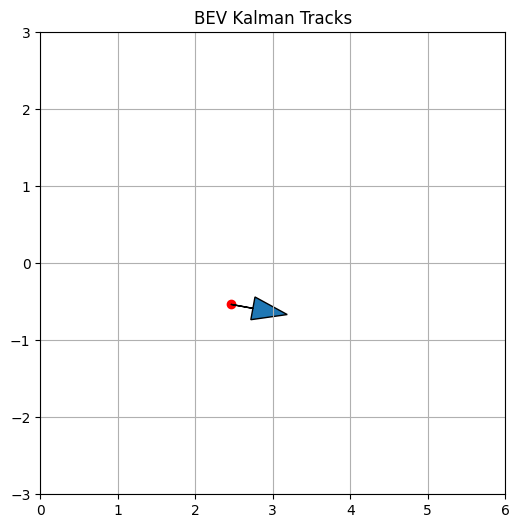

In [ ]:
plt.figure(figsize=(6,6))
for t in tracks:
    x,y = t["kf"].pos
    vx,vy = t["kf"].vel
    plt.scatter(x,y,c='r')
    plt.arrow(x,y,vx,vy,head_width=0.3)

plt.xlim(0,6)
plt.ylim(-3,3)
plt.title("BEV Kalman Tracks")
plt.grid()
plt.show()

In [ ]:
!pip install imageio imageio-ffmpeg

In [ ]:
import imageio
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

In [ ]:
video_writer = imageio.get_writer(
    "/content/nuscenes_tracking.mp4",
    fps=5,
    codec="libx264"
)

In [ ]:
overlay = img.copy()

# Draw YOLO boxes
for b in boxes:
    x1,y1,x2,y2 = map(int,b)
    cv2.rectangle(overlay,(x1,y1),(x2,y2),(0,255,0),2)

# Draw Kalman tracks
for t in tracks:
    x,y = t["kf"].pos
    vx,vy = t["kf"].vel

    # Project BEV point back to image (approx: using centroid match)
    cv2.putText(
        overlay,
        f"ID {t['id']}",
        (int(x1), int(y1-5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6, (255,0,0), 2
    )

# Write frame
video_writer.append_data(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))

In [ ]:
video_writer.close()

In [ ]:
from IPython.display import HTML
HTML("""
<video width="640" controls>
  <source src="nuscenes_tracking.mp4" type="video/mp4">
</video>
""")

In [ ]:
bev_frames = []

In [ ]:
import io
from PIL import Image

fig, ax = plt.subplots(figsize=(5,5))

# Measurements
for m in fused:
    ax.scatter(m[0], m[1], c="gray", s=20)

# Tracks
for t in tracks:
    x,y = t["kf"].pos
    vx,vy = t["kf"].vel
    ax.scatter(x,y,c="red")
    ax.arrow(x,y,vx,vy,head_width=0.4,color="red")
    ax.text(x+0.5,y+0.5,f"{t['id']}",color="red")

ax.set_xlim(-30,30)
ax.set_ylim(-30,30)
ax.set_title("BEV Kalman Tracking")
ax.grid()

# Convert figure → image
buffer = io.BytesIO()
plt.savefig(buffer, format='png')
buffer.seek(0)
image = np.array(Image.open(buffer))

bev_frames.append(image)
plt.close(fig)

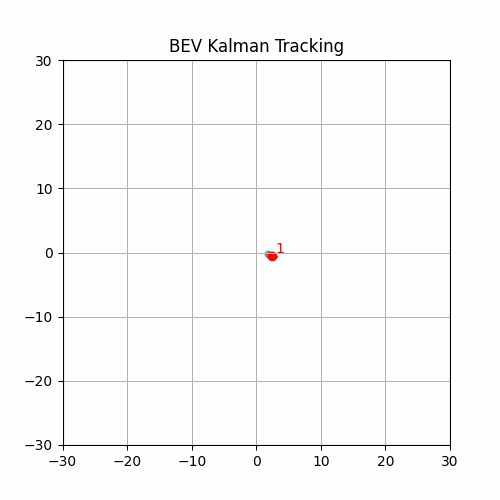

In [ ]:
import imageio
from IPython.display import Image, display

imageio.mimsave(
    "/content/kalman_bev.gif",
    bev_frames,
    fps=5
)

display(Image(filename="/content/kalman_bev.gif"))